# Milky Way-like Potentials

galpy ships several pre-built Milky Way-like potentials from the literature.
This notebook shows how to use them and compare their properties.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import MWPotential2014, mwpotentials
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## MWPotential2014

`MWPotential2014` is galpy's default Milky Way model from
[Bovy (2015)](https://arxiv.org/abs/1412.3451). This potential was fit to a large
variety of data on the Milky Way and thus serves as both a simple and
accurate model for the Milky Way's potential. Note that this potential assumes a circular
velocity of 220 km/s at the solar radius at 8 kpc.

It consists of three components and is defined as:

```python
bp = PowerSphericalPotentialwCutoff(alpha=1.8, rc=1.9/8., normalize=0.05)
mp = MiyamotoNagaiPotential(a=3./8., b=0.28/8., normalize=.6)
np = NFWPotential(a=16/8., normalize=.35)
MWPotential2014 = bp + mp + np
```

which gives

In [2]:
print(MWPotential2014)
print(f"\nv_circ(R_0) = {MWPotential2014.vcirc(1.0):.4f} v_0")

CompositePotential of 3 potentials:
	PowerSphericalPotentialwCutoff with internal parameters: amp=0.029994597188218296, alpha=1.8, rc=0.2375
	MiyamotoNagaiPotential with internal parameters: amp=0.7574802019371595, a=0.375, b=0.035
	NFWPotential with internal parameters: amp=4.852230533527998, a=2.0
and physical outputs off

v_circ(R_0) = 1.0000 v_0


### Adjusting the halo mass

The mass of the dark-matter halo in `MWPotential2014` is on the low side of
estimates of the Milky Way's halo mass. If you want to adjust it, for
example making it 50% larger, you can simply multiply the halo part of
`MWPotential2014` by 1.5 (this type of multiplication works for
*any* potential in galpy):

In [3]:
from copy import deepcopy

MWPotential2014_heavier_halo = deepcopy(MWPotential2014)
MWPotential2014_heavier_halo[2] *= 1.5
print(f"Original halo NFW amp: {MWPotential2014[2]._amp:.4f}")
print(f"Heavier halo NFW amp:  {MWPotential2014_heavier_halo[2]._amp:.4f}")

Original halo NFW amp: 4.8522
Heavier halo NFW amp:  7.2783


### Adding a supermassive black hole at the Galactic center

If one wants to add the supermassive black hole at the Galactic
center, this can be done using a `KeplerPotential`:

In [4]:
from galpy.potential import KeplerPotential
from galpy.util import conversion

# Add a 4 x 10^6 Msun black hole at the Galactic center
MWPotential2014wBH = MWPotential2014 + KeplerPotential(
    amp=4 * 10**6.0 / conversion.mass_in_msol(220.0, 8.0)
)
print("MWPotential2014 with BH components:")
for p in MWPotential2014wBH:
    print(f"  {type(p).__name__}")

MWPotential2014 with BH components:
  PowerSphericalPotentialwCutoff
  MiyamotoNagaiPotential
  NFWPotential
  KeplerPotential


### Adding dynamical friction

If you want to take into account dynamical friction for, say, an object of
mass $5\times 10^{10}\,M_\odot$ and a half-mass radius of 5 kpc, you can use `ChandrasekharDynamicalFrictionForce`. This can be done with astropy units:

In [5]:
from galpy.potential import ChandrasekharDynamicalFrictionForce
from astropy import units

cdf = ChandrasekharDynamicalFrictionForce(
    GMs=5.0 * 10.0**10.0 * units.Msun, rhm=5.0 * units.kpc, dens=MWPotential2014
)
MWPotential2014wDF = MWPotential2014 + cdf
print("MWPotential2014 with dynamical friction components:")
print(MWPotential2014wDF)

MWPotential2014 with dynamical friction components:
CompositePotential of 4 potentials:
	PowerSphericalPotentialwCutoff with internal parameters: amp=0.029994597188218296, alpha=1.8, rc=0.2375
	MiyamotoNagaiPotential with internal parameters: amp=0.7574802019371595, a=0.375, b=0.035
	NFWPotential with internal parameters: amp=4.852230533527998, a=2.0
	ChandrasekharDynamicalFrictionForce with internal parameters: amp=6.979199431427398, gamma=1.0, rhm=0.625, sigmar=<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline object at 0x7f44e2e22cf0>, minr=0.0001, maxr=25.0
and physical outputs off


Alternatively, you can convert the parameters directly to galpy natural units:

In [6]:
cdf_natunits = ChandrasekharDynamicalFrictionForce(
    GMs=5.0 * 10.0**10.0 / conversion.mass_in_msol(220.0, 8.0),
    rhm=5.0 / 8.0,
    dens=MWPotential2014,
)
MWPotential2014wDF_natunits = MWPotential2014 + cdf_natunits

### Using MWPotential2014 with gyrfalcON

See the [Using galpy Potentials in Other Codes](other_codes.ipynb) tutorial for details on using galpy potentials with NEMO's gyrfalcON, AMUSE, and other frameworks.

## Other Milky Way potentials

galpy also contains other models for the Milky Way's potential
from the literature in the `galpy.potential.mwpotentials` module
(which also contains `MWPotential2014`). Currently, these are:

- `McMillan17`: the potential model from [McMillan (2017)](https://ui.adsabs.harvard.edu/abs/2017MNRAS.465...76M)
- `Irrgang13I`: model I from [Irrgang et al. (2013)](https://ui.adsabs.harvard.edu/abs/2013A%26A...549A.137I), which is an updated version of the classic Allen & Santillan (1991)
- `Irrgang13II` and `Irrgang13III`: model II and III from [Irrgang et al. (2013)](https://ui.adsabs.harvard.edu/abs/2013A%26A...549A.137I)
- `Cautun20`: the potential model from [Cautun et al. (2020)](https://ui.adsabs.harvard.edu/abs/2020MNRAS.494.4291C)
- `DehnenBinney98I`, `DehnenBinney98II`, `DehnenBinney98III`, and `DehnenBinney98IV`: models 1 through 4 from [Dehnen & Binney (1998)](https://ui.adsabs.harvard.edu/abs/1998MNRAS.294..429D/abstract)

Unlike `MWPotential2014`, these potentials have physical units
turned on, using as the unit scaling parameters `ro` and `vo` the
distance to the Galactic center and the circular velocity at the Sun's
radius of each potential. These can be obtained using the
`galpy.util.conversion.get_physical` function. For example, for the `McMillan17` potential from [McMillan (2017)](https://ui.adsabs.harvard.edu/abs/2017MNRAS.465...76M):

In [7]:
from galpy.util.conversion import get_physical

# McMillan (2017) potential
mcm17 = mwpotentials.McMillan17
print("Components of McMillan17 potential:")
for p in mcm17:
    print(f"  {type(p).__name__}")
print(f"\nPhysical units: {get_physical(mcm17)}")

Components of McMillan17 potential:
  DiskSCFPotential
  NFWPotential
  SCFPotential

Physical units: {'ro': 8.21, 'vo': 233.1}


The [Cautun et al. (2020)](https://ui.adsabs.harvard.edu/abs/2020MNRAS.494.4291C) potential includes adiabatic contraction of the dark-matter halo:

In [8]:
import warnings

warnings.filterwarnings("ignore")
# Cautun et al. (2020)
cautun20 = mwpotentials.Cautun20
print("Components of Cautun20 potential:")
for p in cautun20:
    print(f"  {type(p).__name__}")
print(f"\nPhysical units: {get_physical(cautun20)}")

Components of Cautun20 potential:
  AdiabaticContractionWrapperPotential
  DiskSCFPotential
  SCFPotential
  PowerSphericalPotentialwCutoff

Physical units: {'ro': 8.122, 'vo': 229}


The Irrgang et al. (2013) Model I is an updated version of the classic [Allen & Santillan (1991)](https://ui.adsabs.harvard.edu/abs/1991RMxAA..22..255A) potential:

In [9]:
# Irrgang et al. (2013), Model I
irr13 = mwpotentials.Irrgang13I
print("Components of Irrgang13I potential:")
for p in irr13:
    print(f"  {type(p).__name__}")
print(f"\nPhysical units: {get_physical(irr13)}")

Components of Irrgang13I potential:
  PlummerPotential
  MiyamotoNagaiPotential
  SCFPotential

Physical units: {'ro': 8.4, 'vo': 242.0}


The [Dehnen & Binney (1998)](https://ui.adsabs.harvard.edu/abs/1998MNRAS.294..429D/abstract) models are a classic set of Milky Way models:

In [10]:
# Dehnen & Binney (1998), Model I
db98 = mwpotentials.DehnenBinney98I
print("Components of DehnenBinney98I potential:")
for p in db98:
    print(f"  {type(p).__name__}")
print(f"\nPhysical units: {get_physical(db98)}")

Components of DehnenBinney98I potential:
  SCFPotential
  DiskSCFPotential
  TwoPowerTriaxialPotential

Physical units: {'ro': 8.0, 'vo': 222.0}


Other available models not loaded here for brevity:

In [11]:
# Other available models (not loaded here for brevity)
print("Other available Milky Way potentials in mwpotentials:")
print("  Irrgang13II, Irrgang13III")
print("  DehnenBinney98II, DehnenBinney98III, DehnenBinney98IV")

Other available Milky Way potentials in mwpotentials:
  Irrgang13II, Irrgang13III
  DehnenBinney98II, DehnenBinney98III, DehnenBinney98IV


### Initializing orbits in these potentials

When integrating an orbit in these potentials and either initializing the
orbit using observed coordinates or converting the integrated orbit to
observed coordinates, it is important to use the same unit-conversion
parameters (otherwise an error will be raised). The `get_physical` function returns the unit-conversion parameters as a dictionary,
so they can be easily passed to other functions using `**get_physical(...)`. For example, to obtain
the orbit of the Sun in the `McMillan17` potential:

```python
from galpy.orbit import Orbit
o = Orbit(**get_physical(McMillan17))
```

### The Sun's orbit in different MW potentials

As an example, we integrate the Sun's orbit for 10 Gyr in
`MWPotential2014`, `McMillan17`, and `Irrgang13I`.

galpy's `.plot()` methods create a new figure by default. To overlay multiple plots on the same figure, pass `gcf=True` ('get current figure') to reuse the existing figure.

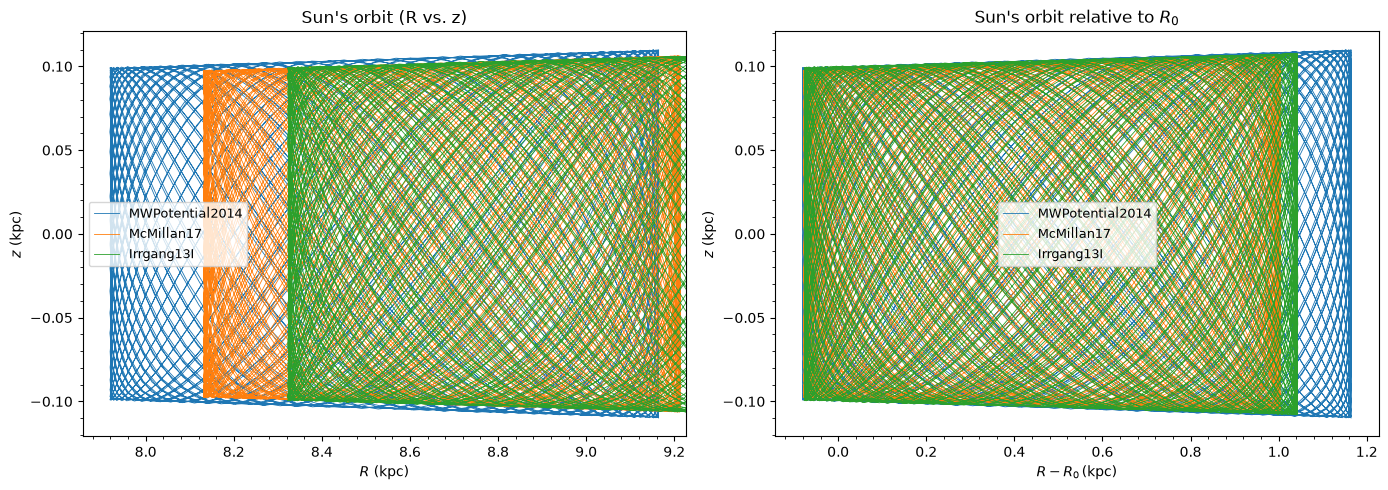

In [12]:
from galpy.orbit import Orbit
from astropy import units as u

times = numpy.linspace(0.0, 10.0, 3001) * u.Gyr
o_mwp14 = Orbit(ro=8.0, vo=220.0)  # Need to set these by hand for MWPotential2014
o_mcm17 = Orbit(**get_physical(mcm17))
o_irrI = Orbit(**get_physical(irr13))
o_mwp14.integrate(times, MWPotential2014)
o_mcm17.integrate(times, mcm17)
o_irrI.integrate(times, irr13)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
o_mwp14.plot(gcf=True, lw=0.6, label="MWPotential2014")
o_mcm17.plot(overplot=True, lw=0.6, label="McMillan17")
o_irrI.plot(overplot=True, lw=0.6, label="Irrgang13I")
plt.legend(fontsize=9)
plt.title("Sun's orbit (R vs. z)")

# Plot relative to each potential's solar radius
plt.sca(axes[1])
o_mwp14.plot(
    d1="R-8.",
    d2="z",
    gcf=True,
    lw=0.6,
    xlabel=r"$R-R_0\,(\mathrm{kpc})$",
    label="MWPotential2014",
)
o_mcm17.plot(
    d1="R-{}".format(get_physical(mcm17)["ro"]),
    d2="z",
    overplot=True,
    lw=0.6,
    label="McMillan17",
)
o_irrI.plot(
    d1="R-{}".format(get_physical(irr13)["ro"]),
    d2="z",
    overplot=True,
    lw=0.6,
    label="Irrgang13I",
)
plt.legend(fontsize=9)
plt.title(r"Sun's orbit relative to $R_0$")
plt.tight_layout();

Much of the difference between the orbit of the Sun in these different potentials is due to the different present Galactocentric radius of the Sun, if we simply plot the difference with respect to the present Galactocentric radius, they agree better.

## Comparing rotation curves

We can compare the rotation curves of these different Milky Way models using
`plotRotcurve`. Note that for `MWPotential2014` we need to set `ro` and `vo` explicitly,
because it has physical units turned off, while the other potentials have physical units
turned on by default.

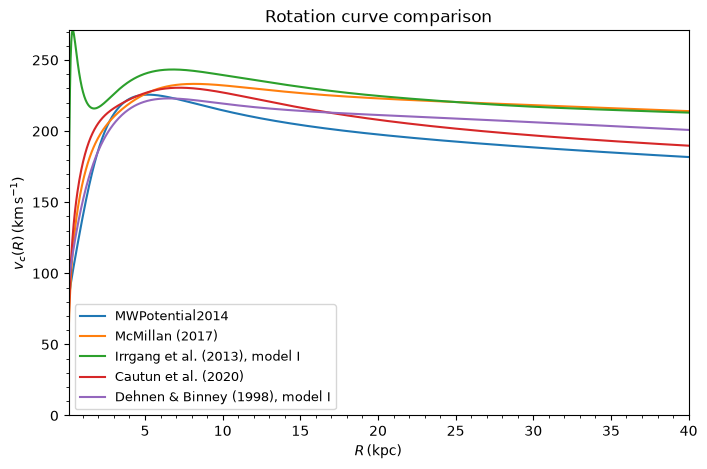

In [13]:
from galpy.potential import plotRotcurve

fig, ax = plt.subplots(figsize=(8, 5))
plotRotcurve(MWPotential2014, label=r"MWPotential2014", ro=8.0, vo=220.0, gcf=True)
plotRotcurve(mcm17, overplot=True, label=r"McMillan (2017)")
plotRotcurve(irr13, overplot=True, label=r"Irrgang et al. (2013), model I")
plotRotcurve(cautun20, overplot=True, label=r"Cautun et al. (2020)")
plotRotcurve(db98, overplot=True, label=r"Dehnen & Binney (1998), model I")
plt.legend(fontsize=9)
plt.title("Rotation curve comparison");

## Physical properties

We can compute various physical properties of `MWPotential2014`. Since it uses
natural units (physical units are off), we need to convert to physical units
using the `galpy.util.conversion` module with `ro=8.` kpc and `vo=220.` km/s.

In [14]:
ro, vo = 8.0, 220.0

# Local dark-matter density (from the halo component, index 2 in MWPotential2014)
rho_dm = MWPotential2014[2].dens(1.0, 0.0) * conversion.dens_in_msolpc3(vo, ro)
print(f"Local DM density: {rho_dm:.4f} Msun/pc^3")

Local DM density: 0.0075 Msun/pc^3


The local dark-matter density is consistent with observational estimates (e.g., [Bovy & Tremaine (2012)](http://adsabs.harvard.edu/abs/2012ApJ...756...89B); [Bovy & Rix 2013](http://adsabs.harvard.edu/abs/2013ApJ...779..115B)).

We can also compute the vertical force and surface density at 1.1 kpc above the plane, which can be compared to observational constraints (e.g., [Bovy & Rix 2013](http://adsabs.harvard.edu/abs/2013ApJ...779..115B)):

In [15]:
# Vertical force and surface density at 1.1 kpc
# The vertical force at 1.1 kpc above the plane at the solar radius:
zforce_11 = -MWPotential2014.zforce(1.0, 1.1 / 8.0) * conversion.force_in_pcMyr2(vo, ro)
print(f"Vertical force at 1.1 kpc: {zforce_11:.4f} pc/Myr^2")

# Expressed as an equivalent surface density (dividing by 2*pi*G):
surfdens_11 = -MWPotential2014.zforce(1.0, 1.1 / 8.0) * conversion.force_in_2piGmsolpc2(
    vo, ro
)
print(f"Surface density within 1.1 kpc (from zforce): {surfdens_11:.1f} Msun/pc^2")

# Can also compute by integrating the density directly:
from scipy import integrate

z_max = 1.1 / ro  # in natural units
Sigma, _ = integrate.quad(
    lambda z: potential.evaluateDensities(MWPotential2014, 1.0, z), -z_max, z_max
)
Sigma_phys = Sigma * conversion.surfdens_in_msolpc2(vo, ro)
print(
    f"Surface density within 1.1 kpc (from density integration): {Sigma_phys:.1f} Msun/pc^2"
)

Vertical force at 1.1 kpc: 2.0259 pc/Myr^2
Surface density within 1.1 kpc (from zforce): 71.7 Msun/pc^2
Surface density within 1.1 kpc (from density integration): 67.5 Msun/pc^2


The escape velocity at the solar radius can be compared to observational estimates (e.g., [Smith et al. 2007](http://adsabs.harvard.edu/abs/2007MNRAS.379..755S); [Piffl et al. 2014](http://adsabs.harvard.edu/abs/2014A%26A...562A..91P)):

In [16]:
# Escape velocity at the solar radius
# v_esc = sqrt(2 * [Phi(inf) - Phi(R)])
# For MWPotential2014, Phi(inf) = 0 for the NFW and other components
vesc = MWPotential2014.vesc(1.0) * vo
print(f"Escape velocity at R_0 in MWPotential2014: {vesc:.1f} km/s")

Escape velocity at R_0 in MWPotential2014: 513.0 km/s


## The old MWPotential (deprecated)

An older version `galpy.potential.MWPotential` of
`MWPotential2014` that was *not* fit to data on the Milky Way is
defined as:

```python
mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=.6)
np = NFWPotential(a=4.5, normalize=.35)
hp = HernquistPotential(a=0.6/8, normalize=0.05)
MWPotential = mp + np + hp
```

`MWPotential2014` supersedes `MWPotential` and the use of the old `MWPotential` is no longer recommended.